# MBH-Seg25

* Contents

1. Patient Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> 1.4 Patient
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    <br> 2.3 Windowing
    3. Slice level Class
    4. Visualization
    
2. Dataset Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    3. Class
    <br> 3.1 Number of Bleed
    <br> 3.2 Type of Bleed
    <br> 3.3 Volume of Bleed
    4. Visualization

3. nnUNet Dataset 구성
<br> class imbalance 고려

---

In [3]:
import os
import re
from pathlib import Path
from collections import Counter

from scipy import ndimage
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## 1. Patient Unit Analysis

### 1. Basic Info

#### 1.1 Path

In [ ]:
# annotator별 등장 케이스 수
per_annot_count = Counter()
for key in common_keys:
    for aid in cases[key]["annot_paths"]:
        per_annot_count[aid] += 1

print("annotator별 등장 케이스 수:", dict(sorted(per_annot_count.items())))

In [6]:
# dataset, image, mask
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")
SPLIT_ROOTS = {
    "train": DATA_ROOT / "mbhseg25" / "train",
    "val": DATA_ROOT / "mbhseg25" / "val",
}

IMAGE_FILENAME = "image.nii.gz"
ANNOTATOR_ID = 3
MASK_FILENAME = f"label_annot_{ANNOTATOR_ID}.nii.gz"

#### 1.2 Class Mapping 

In [7]:
# BHSD와 동일한 클래스 체계 확인됨 (voxel value 0~5)
class_map = {
    0: 'background',
    1: 'epidural',
    2: 'intraparenchymal',
    3: 'intraventricular',
    4: 'subarachnoid',
    5: 'subdural',
}

class_names = {
    1: 'EDH',
    2: 'IPH', 
    3: 'IVH', 
    4: 'SAH', 
    5: 'SDH'
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (255, 255, 0),
}

#### 1.3 Dataset

In [8]:
# annotator #3 기준 dataset
case_pattern = re.compile(r"^(ID_[a-f0-9]+)_(ID_[a-f0-9]+)$")

image_map = {}
mask_map = {}
case_split = {} # case > train or val

for split, root in SPLIT_ROOTS.items():
    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        if not case_pattern.match(case_dir.name):
            continue
        
        image_path = case_dir / IMAGE_FILENAME
        mask_path = case_dir / MASK_FILENAME
        
        if image_path.exists():
            image_map[case_dir.name] = image_path
        if mask_path.exists():
            mask_map[case_dir.name] = mask_path
        case_split[case_dir.name] = split
common_keys = sorted(set(image_map) & set(mask_map))

print(f"전체 이미지 개수:", len(image_map))
print(f"annotator {ANNOTATOR_ID} 마스크 개수:", len(mask_map))
print("Matched Pair 개수:", len(common_keys))
print("Image only:", len(set(image_map) - set(mask_map)))
print("Mask only:", len(set(mask_map) - set(image_map)))
print("\ncase per split:")
print(pd.Series([case_split[k] for k in common_keys]).value_counts())

전체 이미지 개수: 240
annotator 3 마스크 개수: 240
Matched Pair 개수: 240
Image only: 0
Mask only: 0

case per split:
train    192
val       48
Name: count, dtype: int64


#### 1.4 Patient

In [9]:
# patient 1
patient_key = common_keys[0]
print("선택 환자:", patient_key)
print("이미지 경로:", image_map[patient_key])
print("마스크 경로:", mask_map[patient_key])
print("split:", case_split[patient_key])

선택 환자: ID_0219ef88_ID_e5c1a31210
이미지 경로: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/mbhseg25/val/ID_0219ef88_ID_e5c1a31210/image.nii.gz
마스크 경로: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/mbhseg25/val/ID_0219ef88_ID_e5c1a31210/label_annot_3.nii.gz
split: val


In [24]:
# SimplTK.Image
# 3차원 의료영상 객체 
img_sitk = sitk.ReadImage(str(image_map[patient_key]))
mask_sitk = sitk.ReadImage(str(mask_map[patient_key]))

# Numpy Array 
img_arr = sitk.GetArrayFromImage(img_sitk)
mask_arr = sitk.GetArrayFromImage(mask_sitk)

In [25]:
num_slices = 15
print("슬라이스 배열 개수:", len(img_arr))
print("15번 슬라이스 배열:\n", img_arr[num_slices])
print("15번 슬라이스 배열 크기:", img_arr[num_slices].shape)
print("\n")
print("15번 슬라이스 마스크:\n", mask_arr[num_slices])

슬라이스 배열 개수: 31
15번 슬라이스 배열:
 [[-2048 -2048 -2048 ... -2048 -2048 -2048]
 [-2048 -2048 -2048 ... -2048 -2048 -2048]
 [-2048 -2048 -2048 ... -2048 -2048 -2048]
 ...
 [-2048 -2048 -2048 ... -2048 -2048 -2048]
 [-2048 -2048 -2048 ... -2048 -2048 -2048]
 [-2048 -2048 -2048 ... -2048 -2048 -2048]]
15번 슬라이스 배열 크기: (512, 512)


15번 슬라이스 마스크:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [26]:
# 병변이 있는 배열 쪽 확대한 배열 + 같이 시각화 
target_slice_img = img_arr[num_slices]
target_slice_mask = mask_arr[num_slices]

# 병변이 있는 좌표 찾기 -> bounding box
ys, xs = np.where(target_slice_mask > 0)

if len(xs) == 0:
    print(f"{num_slices}번 슬라이스에는 병변이 없습니다.")
else:
    margin = 10  # 여백
    y0, y1 = max(ys.min() - margin, 0), min(ys.max() + margin, target_slice_mask.shape[0])
    x0, x1 = max(xs.min() - margin, 0), min(xs.max() + margin, target_slice_mask.shape[1])

    cropped_img = target_slice_img[y0:y1, x0:x1]
    cropped_mask = target_slice_mask[y0:y1, x0:x1]

    print("crop 영역 (y0:y1, x0:x1):", (y0, y1, x0, x1))
    print("crop된 이미지 배열:\n", cropped_img)
    print("\ncrop된 마스크 배열:\n", cropped_mask)

crop 영역 (y0:y1, x0:x1): (np.int64(107), np.int64(249), np.int64(313), np.int64(404))
crop된 이미지 배열:
 [[ 277  316  362 ... -989 -992 -991]
 [ 196  234  279 ... -989 -990 -989]
 [ 128  158  197 ... -986 -988 -987]
 ...
 [  30   31   30 ...  625  988 1305]
 [  31   31   30 ...  510  861 1213]
 [  31   30   31 ...  418  751 1126]]

crop된 마스크 배열:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
# annotator별 등장 케이스 수
per_annot_count = Counter()
for key in common_keys:
    for aid in cases[key]["annot_paths"]:
        per_annot_count[aid] += 1

print("annotator별 등장 케이스 수:", dict(sorted(per_annot_count.items())))

annotator별 등장 케이스 수: {1: 120, 2: 115, 3: 192, 4: 44}


In [27]:
print(img_sitk)

Image (0x5cb365652dd0)
  RTTI typeinfo:   itk::Image<int, 3u>
  Reference Count: 1
  Modified Time: 2501
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (none)
  Source output name: (none)
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 2475
  UpdateMTime: 2497
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 31]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 31]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 31]
  Spacing: [0.488281, 0.488281, 5.08501]
  Origin: [-125, -102.03, 1.41008]
  Direction: 
1 0 0
0 0.983255 0.182236
0 -0.182236 0.983255

  IndexToPointMatrix: 
0.488281 0 0
0 0.480105 0.926673
0 -0.0889824 4.99987

  PointToIndexMatrix: 
2.048 0 0
0 2.01371 -0.373219
0 0.0358378 0.193363

  Inverse Direction: 
1 0 0
0 0.983255 -0.182236
0 0.182236 0.983255

  PixelContainer: 
    ImportImageContaine

In [ ]:
# 주요 정보 확인
print("이미지 정보")
print("크기:", img_sitk.GetSize())
print("타입:", img_sitk.GetPixelIDTypeAsString())
print("==="*15)
print("마스크 정보")
print("크기:", mask_sitk.GetSize())
print("타입:", mask_sitk.GetPixelIDTypeAsString())

# spacing, origin, direction
direction = np.array(img_sitk.GetDirection()).reshape(3, 3)
spacing = np.array(img_sitk.GetSpacing())
origin = np.array(img_sitk.GetOrigin())
affine = np.eye(4)

print("==="*15)
print("Spacing:", spacing)
print("Origin:\n", direction)
affine[:3, :3] = direction * spacing
affine[:3, 3] = origin
print("Affine:\n", affine)

orient_filter = sitk.DICOMOrientImageFilter()
print("Orientation:", 
orient_filter.GetOrientationFromDirectionCosines(img_sitk.GetDirection()))
# LAS: Left, Posterior, Superior

이미지 정보
크기: (512, 512, 31)
타입: 32-bit signed integer
마스크 정보
크기: (512, 512, 31)
타입: 16-bit unsigned integer
Spacing: [0.48828101 0.48828101 5.08501482]
Origin:
 [[ 1.          0.          0.        ]
 [ 0.          0.98325483  0.18223596]
 [ 0.         -0.18223596  0.98325483]]
Affine:
 [[ 4.88281012e-01  0.00000000e+00  0.00000000e+00 -1.25000000e+02]
 [ 0.00000000e+00  4.80104661e-01  9.26672548e-01 -1.02029640e+02]
 [ 0.00000000e+00 -8.89823598e-02  4.99986537e+00  1.41008365e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Orientation: LPS


### 2. 3D CT

#### 2.1 Min/Max

In [29]:
# min / max, percentiles
flat = img_arr.astype(np.float32).ravel()
percentiles = np.percentile(flat, [0, 0.5, 1, 5, 50, 95, 99, 99.5, 100])
print("min/max:", flat.min(), flat.max())
print("percentiles:", percentiles)

min/max: -2048.0 3023.0
percentiles: [-2048. -2048. -2048. -2048.  -987.   541.  1317.  1432.  3023.]


In [30]:
min_value = flat.min()
min_ratio = (flat == min_value).mean()
print(f"min값({min_value}) 비율: {min_ratio:.1%}")

min값(-2048.0) 비율: 35.6%


#### 2.2 HU

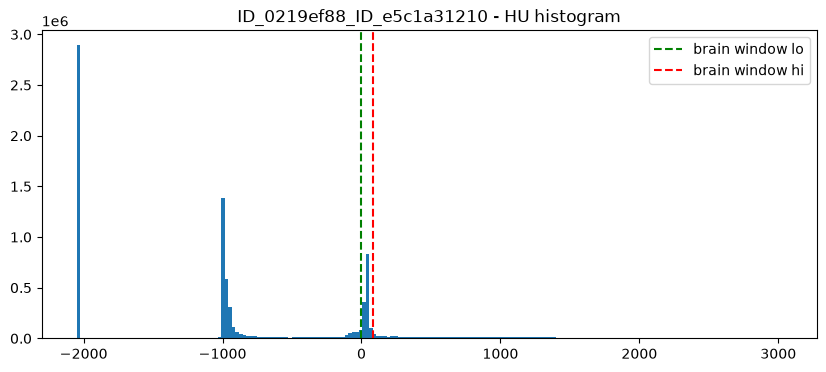

In [31]:
plt.figure(figsize=(10, 4))
plt.hist(flat, bins=200)
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.legend()
plt.title(f'{patient_key} - HU histogram')
plt.show()

#### 2.3 Windowing w/, w/o

In [37]:
# windowing 적용 함수
def apply_window(slice_hu, window_level=40, window_width=80):
    # HU 0 ~ 80 사이
    lo = window_level - window_width / 2 # HU 0
    hi = window_level + window_width / 2 # HU 80
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

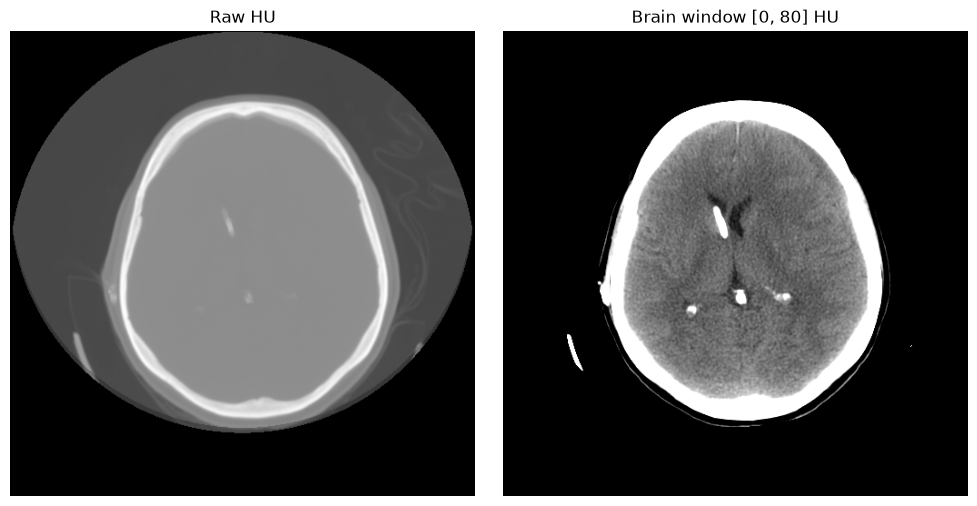

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr[num_slices], cmap='gray')
axes[0].set_title('Raw HU')
axes[0].axis('off')
axes[1].imshow(apply_window(img_arr[num_slices]), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Brain window [0, 80] HU')
axes[1].axis('off')
plt.tight_layout()

### 3. Class

Slice level + Voxel level

In [ ]:
# class
n_slices = len(img_arr)
rows = []

for z in range(n_slices):
    classes_in_slice = sorted(set(np.unique(mask_arr[z]).tolist()) - {0})
    rows.append({
        'slice': z,
        'n_classes': len(classes_in_slice),
        'classes': ', '.join([class_names[c] for c in classes_in_slice]),
        'fg_voxels': int((mask_arr[z] > 0).sum()), # 병변의 픽셀 개수 
    })

df_slices = pd.DataFrame(rows)
display(df_slices[df_slices['n_classes'] > 0])

,slice,n_classes,classes,fg_voxels
11,11,1,SDH,490
12,12,1,SDH,480
13,13,1,SDH,898
14,14,1,SDH,1187
15,15,1,SDH,1463
16,16,1,SDH,1619
17,17,1,SDH,1842
18,18,1,SDH,1890
19,19,1,SDH,2434
20,20,1,SDH,2301


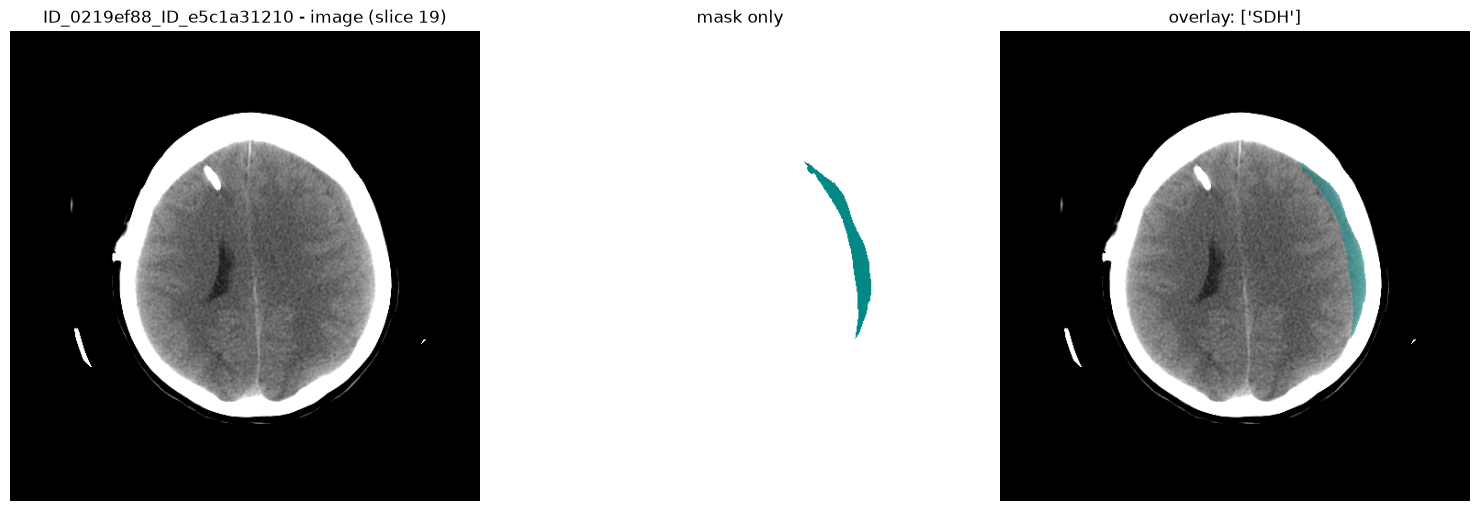

In [36]:
best_z = int(df_slices['fg_voxels'].idxmax())
windowed_slice = apply_window(img_arr[best_z])
mask_slice = mask_arr[best_z]
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{patient_key} - image (slice {best_z})')
axes[0].axis('off')


n_classes = max(class_colors.keys()) + 1   # 5 + 1 = 6 (0~5)
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors.items():
    colors_rgb[cls] = np.array(rgb) / 255
custom_cmap = ListedColormap(colors_rgb)

mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)

axes[1].set_facecolor('black')  # masked(배경) 영역이 이 색으로 보임 → "색 없음" 효과
axes[1].imshow(mask_only_display, cmap=custom_cmap, vmin=0, vmax=5)
axes[1].set_title('mask only')
axes[1].axis('off')

axes[2].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(mask_overlay, cmap=custom_cmap, alpha=0.5, vmin=0, vmax=5)
present = [class_names[c] for c in np.unique(mask_slice) if c != 0]
axes[2].set_title(f'overlay: {present}')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In [37]:
from ctviewer import CTViewer
CTViewer(img_arr)

interactive(children=(RadioButtons(description='Slice plane selection:', index=2, options=('y-z', 'z-x', 'x-y'…

## 2. Dataset Unit Analysis

### 1. Basic Info

#### 1.1 Path

In [ ]:
# dataset, image, mask
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")
SPLIT_ROOTS = {
    "train": DATA_ROOT / "mbhseg25" / "train",
    "val": DATA_ROOT / "mbhseg25" / "val",
}

IMAGE_FILENAME = "image.nii.gz"
ANNOTATOR_ID = 3
MASK_FILENAME = f"label_annot_{ANNOTATOR_ID}.nii.gz"

### 1.2 Class Mapping

In [ ]:
class_map = {
    0: 'background',
    1: 'epidural',
    2: 'intraparenchymal',
    3: 'intraventricular',
    4: 'subarachnoid',
    5: 'subdural',
}

class_names = {
    1: 'EDH',
    2: 'IPH', 
    3: 'IVH', 
    4: 'SAH', 
    5: 'SDH'
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (255, 255, 0),
}

### 1.3 Dataset

In [39]:
# annotator #3 기준 dataset
case_pattern = re.compile(r"^(ID_[a-f0-9]+)_(ID_[a-f0-9]+)$")

image_map = {}
mask_map = {}
case_split = {} # case > train or val

for split, root in SPLIT_ROOTS.items():
    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        if not case_pattern.match(case_dir.name):
            continue
        
        image_path = case_dir / IMAGE_FILENAME
        mask_path = case_dir / MASK_FILENAME
        
        if image_path.exists():
            image_map[case_dir.name] = image_path
        if mask_path.exists():
            mask_map[case_dir.name] = mask_path
        case_split[case_dir.name] = split
common_keys = sorted(set(image_map) & set(mask_map))

In [ ]:
print(f"전체 이미지 개수:", len(image_map))
print(f"annotator {ANNOTATOR_ID} 마스크 개수:", len(mask_map))
print("Matched Pair 개수:", len(common_keys))
print("Image only:", len(set(image_map) - set(mask_map)))
print("Mask only:", len(set(mask_map) - set(image_map)))
print("\ncase per split:")
print(pd.Series([case_split[k] for k in common_keys]).value_counts())

전체 이미지 개수: 240
annotator 3 마스크 개수: 240
Matched Pair 개수: 240
Image only: 0
Mask only: 0

case per split:
train    192
val       48
Name: count, dtype: int64


In [10]:
# 환자 겹침 확인
def patient_id(filename: str) -> str:
    # ID_{patientID}_ID_{studyID}.nii.gz -> patientID
    return filename.split('_')[1]

case_patient = pd.Series({k: patient_id(k) for k in common_keys})

print("전체 case 수:", len(case_patient))
print("고유 환자 수:", case_patient.nunique())

overlap = case_patient.value_counts()
overlap = overlap[overlap > 1]
print("여러 case를 가진 환자 수:", len(overlap))

전체 case 수: 240
고유 환자 수: 239
여러 case를 가진 환자 수: 1


In [ ]:
# image 정보 확인
sitk.ProcessObject.SetGlobalWarningDisplay(False)
rows = []
orient_filter = sitk.DICOMOrientImageFilter()

for key in common_keys:
    v_img = sitk.ReadImage(str(image_map[key]))

    direction = np.array(v_img.GetDirection()).reshape(3, 3)
    spacing = np.array(v_img.GetSpacing())
    origin = np.array(v_img.GetOrigin())

    affine = np.eye(4)
    affine[:3, :3] = direction * spacing
    affine[:3, 3] = origin

    rows.append({
        'case': key,
        'patient_id': patient_id(key),
        'shape': v_img.GetSize(),
        'dtype': v_img.GetPixelIDTypeAsString(),
        'spacing': tuple(spacing),
        'origin': tuple(origin),
        'orientation': orient_filter.GetOrientationFromDirectionCosines(v_img.GetDirection()),
    })

df_meta = pd.DataFrame(rows)
display(df_meta.head())

print("\n서로 다른 shape 종류 수:", df_meta['shape'].nunique())
print("서로 다른 spacing 종류 수:", df_meta['spacing'].nunique())
print("서로 다른 dtype 종류:", df_meta['dtype'].unique())
print("서로 다른 orientation 종류:", df_meta['orientation'].unique())

,case,patient_id,shape,dtype,spacing,origin,orientation
0,ID_0219ef88_ID_e5c1a31210,0219ef88,"(512, 512, 31)",32-bit signed integer,"(0.4882810115814209, 0.4882810115814209, 5.085...","(-125.0, -102.0296401977539, 1.4100836515426636)",LPS
1,ID_0237f3c9_ID_40015688b9,0237f3c9,"(512, 512, 27)",32-bit signed integer,"(0.4882810115814209, 0.4882810115814209, 5.288...","(-125.0, -162.14190673828125, 25.579936981201172)",LPS
2,ID_029ebbea_ID_563afa0901,029ebbea,"(512, 512, 26)",32-bit signed integer,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, -142.61578369140625, 64.24302673339844)",LPS
3,ID_02b882cc_ID_a4892e60ae,02b882cc,"(512, 512, 30)",32-bit signed integer,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, -123.68586730957031, 47.92484664916992)",LPS
4,ID_02f779fb_ID_c4d7f33559,02f779fb,"(512, 512, 31)",16-bit signed integer,"(0.48828125, 0.48828125, 5.000001907348633)","(-125.0, 10.0, 96.5999755859375)",LPS



서로 다른 shape 종류 수: 22
서로 다른 spacing 종류 수: 159
서로 다른 dtype 종류: <StringArray>
['32-bit signed integer', '16-bit signed integer']
Length: 2, dtype: str
서로 다른 orientation 종류: <StringArray>
['LPS']
Length: 1, dtype: str


In [ ]:
# mask 정보 확인 
sitk.ProcessObject.SetGlobalWarningDisplay(False)

mask_rows = []
orient_filter = sitk.DICOMOrientImageFilter()

for key in common_keys:
    v_mask = sitk.ReadImage(str(mask_map[key]))

    direction = np.array(v_mask.GetDirection()).reshape(3, 3)
    spacing = np.array(v_mask.GetSpacing())
    origin = np.array(v_mask.GetOrigin())

    mask_rows.append({
        'case': key,
        'patient_id': patient_id(key),
        'shape': v_mask.GetSize(),
        'dtype': v_mask.GetPixelIDTypeAsString(),
        'spacing': tuple(spacing),
        'origin': tuple(origin),
        'orientation': orient_filter.GetOrientationFromDirectionCosines(v_mask.GetDirection()),
    })

df_mask_meta = pd.DataFrame(mask_rows)
display(df_mask_meta.head())

print("\n서로 다른 shape 종류 수:", df_mask_meta['shape'].nunique())
print("서로 다른 spacing 종류 수:", df_mask_meta['spacing'].nunique())
print("서로 다른 dtype 종류:", df_mask_meta['dtype'].unique())
print("서로 다른 orientation 종류:", df_mask_meta['orientation'].unique())

,case,patient_id,shape,dtype,spacing,origin,orientation
0,ID_0219ef88_ID_e5c1a31210,0219ef88,"(512, 512, 31)",16-bit unsigned integer,"(0.4882810115814209, 0.4882810115814209, 5.085...","(-125.0, -102.0296401977539, 1.4100836515426636)",LPS
1,ID_0237f3c9_ID_40015688b9,0237f3c9,"(512, 512, 27)",64-bit float,"(0.4882810115814209, 0.4882810115814209, 5.288...","(-125.0, -162.14190673828125, 25.579936981201172)",LPS
2,ID_029ebbea_ID_563afa0901,029ebbea,"(512, 512, 26)",16-bit unsigned integer,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, -142.61578369140625, 64.24302673339844)",LPS
3,ID_02b882cc_ID_a4892e60ae,02b882cc,"(512, 512, 30)",64-bit float,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, -123.68586730957031, 47.92484664916992)",LPS
4,ID_02f779fb_ID_c4d7f33559,02f779fb,"(512, 512, 31)",64-bit float,"(0.48828125, 0.48828125, 5.000001907348633)","(-125.0, 10.0, 96.5999755859375)",LPS



서로 다른 shape 종류 수: 22
서로 다른 spacing 종류 수: 159
서로 다른 dtype 종류: <StringArray>
['16-bit unsigned integer', '64-bit float']
Length: 2, dtype: str
서로 다른 orientation 종류: <StringArray>
['LPS']
Length: 1, dtype: str


In [44]:
compare = df_meta.merge(df_mask_meta, on='case', suffixes=('_img', '_mask'))

mismatch_shape = compare[compare['shape_img'] != compare['shape_mask']]
mismatch_spacing = compare[compare['spacing_img'] != compare['spacing_mask']]

print("image/mask shape 안 맞는 case 수:", len(mismatch_shape))
print("image/mask spacing 안 맞는 case 수:", len(mismatch_spacing))


image/mask shape 안 맞는 case 수: 0
image/mask spacing 안 맞는 case 수: 0


In [45]:
# z 슬라이스 개수 volume 별로 파악
z_rows = []
for key in common_keys:
    v_img = sitk.ReadImage(str(image_map[key]))
    z_rows.append({
        'case': key,
        'patient_id': patient_id(key),
        'n_slices': v_img.GetSize()[2],
    })

df_z = pd.DataFrame(z_rows)
display(df_z)

print("전체 volume 개수:", len(df_z))
print("z 슬라이스 개수 - mean:", df_z['n_slices'].mean())
print("z 슬라이스 개수 - median:", df_z['n_slices'].median())
print("z 슬라이스 개수 - min/max:", df_z['n_slices'].min(), "/", df_z['n_slices'].max())
print("z 슬라이스 개수 - std:", df_z['n_slices'].std())

,case,patient_id,n_slices
0,ID_0219ef88_ID_e5c1a31210,0219ef88,31
1,ID_0237f3c9_ID_40015688b9,0237f3c9,27
2,ID_029ebbea_ID_563afa0901,029ebbea,26
3,ID_02b882cc_ID_a4892e60ae,02b882cc,30
4,ID_02f779fb_ID_c4d7f33559,02f779fb,31
...,...,...,...
235,ID_f551e132_ID_25d41a6cfd,f551e132,30
236,ID_faa3c13d_ID_c31106b8dc,faa3c13d,29
237,ID_fb6d0135_ID_497840f16e,fb6d0135,26
238,ID_fcbe7eda_ID_5726e1c630,fcbe7eda,32


전체 volume 개수: 240
z 슬라이스 개수 - mean: 32.166666666666664
z 슬라이스 개수 - median: 31.0
z 슬라이스 개수 - min/max: 22 / 58
z 슬라이스 개수 - std: 4.560762861633544


### 2. 3D CT

#### 2.1 Min/Max

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

hu_rows = []
for key in common_keys:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(image_map[key]))).astype(np.float32) # 모든 hu값을 한 줄로 
    flat = arr.ravel()
    p = np.percentile(flat, [0.5, 1, 5, 50, 95, 99, 99.5])
    hu_rows.append({
        'case': key,
        'min': round(float(flat.min()), 2),
        'max': round(float(flat.max()), 2),
        'p0.5': round(float(p[0]), 2),
        'p1': round(float(p[1]), 2),
        'p5': round(float(p[2]), 2),
        'p50': round(float(p[3]), 2),
        'p95': round(float(p[4]), 2),
        'p99': round(float(p[5]), 2),
        'p99.5': round(float(p[6]), 2),
    })

df_hu = pd.DataFrame(hu_rows)
display(df_hu.describe())

,min,max,p0.5,p1,p5,p50,p95,p99,p99.5
count,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00,240.00
mean,-2577.77,4739.08,-1763.32,-1762.07,-1759.26,-955.05,458.14,1152.85,1294.89
std,5016.66,7134.76,835.16,836.28,838.81,64.08,150.73,197.21,188.53
min,-33762.00,1452.00,-3024.00,-3024.00,-3024.00,-1011.00,76.00,736.00,896.00
25%,-3024.00,1880.00,-2048.00,-2048.00,-2048.00,-986.00,354.25,1018.50,1159.75
50%,-2048.00,2269.00,-1024.00,-1024.00,-1024.00,-970.00,427.00,1149.50,1289.50
75%,-1024.00,3071.00,-1014.00,-1010.00,-1005.00,-949.00,541.25,1283.25,1429.75
max,-1000.00,31701.00,-1000.00,-1000.00,-998.00,-245.00,1161.00,1608.00,1734.00


In [ ]:
worst_min_case = df_hu.loc[df_hu['min'].idxmin(), 'case']
worst_max_case = df_hu.loc[df_hu['max'].idxmax(), 'case']
print("min 극단 케이스:", worst_min_case, df_hu.loc[df_hu['case']==worst_min_case, 'min'].values)
print("max 극단 케이스:", worst_max_case, df_hu.loc[df_hu['case']==worst_max_case, 'max'].values)

min 극단 케이스: ID_0bee00a2_ID_0b9e78b135 [-33762.]
max 극단 케이스: ID_9dce269b_ID_4191982e02 [31701.]


#### 2.2 HU

/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


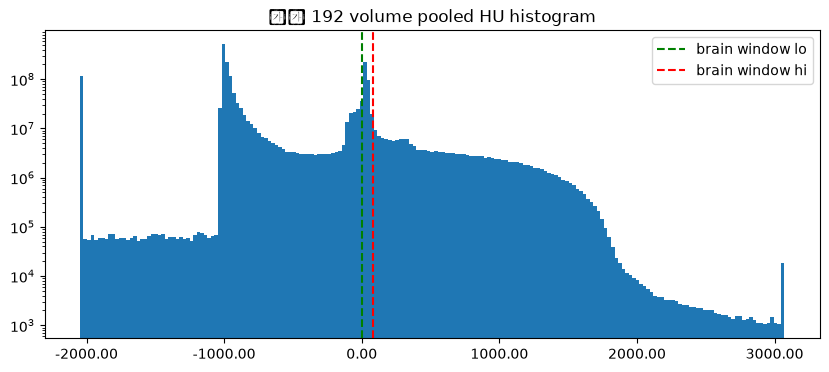

In [48]:
bin_edges = np.round(np.linspace(-2048, 3072, 200), 2)
hist_total = np.zeros(len(bin_edges) - 1)

for key in common_keys:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(image_map[key]))).astype(np.float32)
    counts, _ = np.histogram(arr.ravel(), bins=bin_edges)
    hist_total += counts

plt.figure(figsize=(10, 4))
plt.bar(bin_edges[:-1], hist_total, width=np.diff(bin_edges), align='edge')
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.legend()
plt.title('전체 192 volume pooled HU histogram')
plt.show()

### 3. Class

In [50]:
slice_bleed_counter = Counter()   # 3.1용: 슬라이스당 동시출현 타입 개수
scan_bleed_counter  = Counter()   # 3.1용: 스캔당 동시출현 타입 개수
slice_type_counter  = Counter()   # 3.2용: 타입별 등장 슬라이스 수
scan_type_counter   = Counter()   # 3.2용: 타입별 등장 스캔 수

for key in common_keys:
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    scan_classes_present = set()

    for z in range(mask.shape[0]):
        classes_in_slice = set(np.unique(mask[z]).tolist()) - {0}
        slice_bleed_counter[len(classes_in_slice)] += 1
        for c in classes_in_slice:
            slice_type_counter[c] += 1
        scan_classes_present |= classes_in_slice

    scan_bleed_counter[len(scan_classes_present)] += 1
    for c in scan_classes_present:
        scan_type_counter[c] += 1

In [ ]:
# Number of bleeds (slice/scan level)
df_num_bleeds = pd.DataFrame({
    'n_classes co-occurring': range(6),
    'slice count': [slice_bleed_counter.get(n, 0) for n in range(6)],
    'scan count': [scan_bleed_counter.get(n, 0) for n in range(6)],
})
display(df_num_bleeds)

# Type of bleed (slice/scan level)
df_type_bleed = pd.DataFrame({
    'type': [class_names[c] for c in range(1, 6)],
    'slice count': [slice_type_counter.get(c, 0) for c in range(1, 6)],
    'scan count': [scan_type_counter.get(c, 0) for c in range(1, 6)],
})
display(df_type_bleed)
# 총 슬라이스 + 스캔까지 

,n_classes co-occurring,slice count,scan count
0,0,4716,7
1,1,1864,63
2,2,805,73
3,3,280,75
4,4,51,21
5,5,4,1


,type,slice count,scan count
0,EDH,227,26
1,IPH,1055,147
2,IVH,869,125
3,SAH,1260,124
4,SDH,1127,101


#### 3.1 Number of Bleed

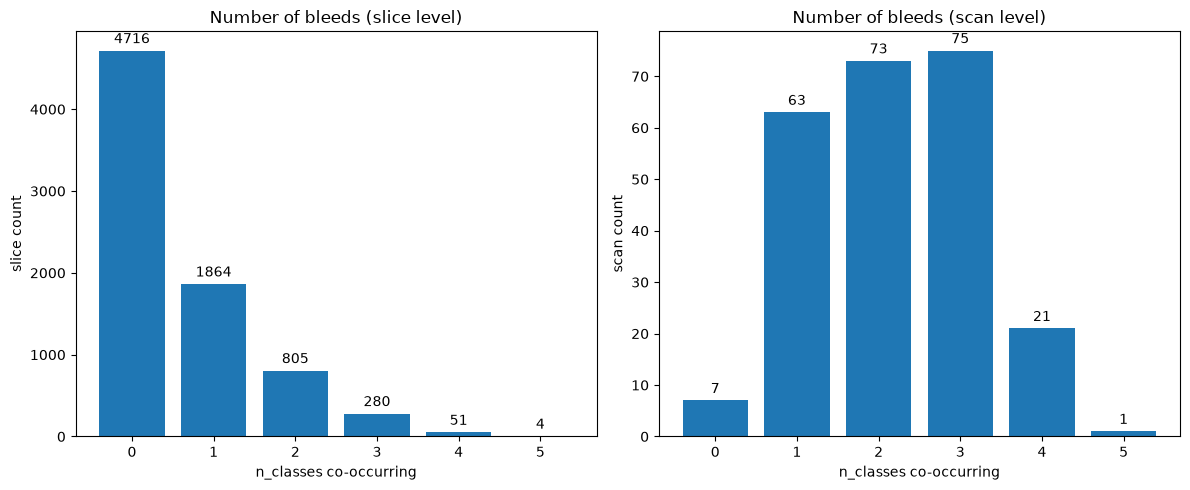

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

slice_x = list(range(6))
slice_y = [slice_bleed_counter.get(n, 0) for n in slice_x]
bars0 = axes[0].bar(slice_x, slice_y)
axes[0].set_title('Number of bleeds (slice level)')
axes[0].set_xlabel('n_classes co-occurring')
axes[0].set_ylabel('slice count')
axes[0].bar_label(bars0, padding=3)

scan_x = list(range(6))
scan_y = [scan_bleed_counter.get(n, 0) for n in scan_x]
bars1 = axes[1].bar(scan_x, scan_y)
axes[1].set_title('Number of bleeds (scan level)')
axes[1].set_xlabel('n_classes co-occurring')
axes[1].set_ylabel('scan count')
axes[1].bar_label(bars1, padding=3)

plt.tight_layout()
plt.show()

#### 3.2 Type of Bleed

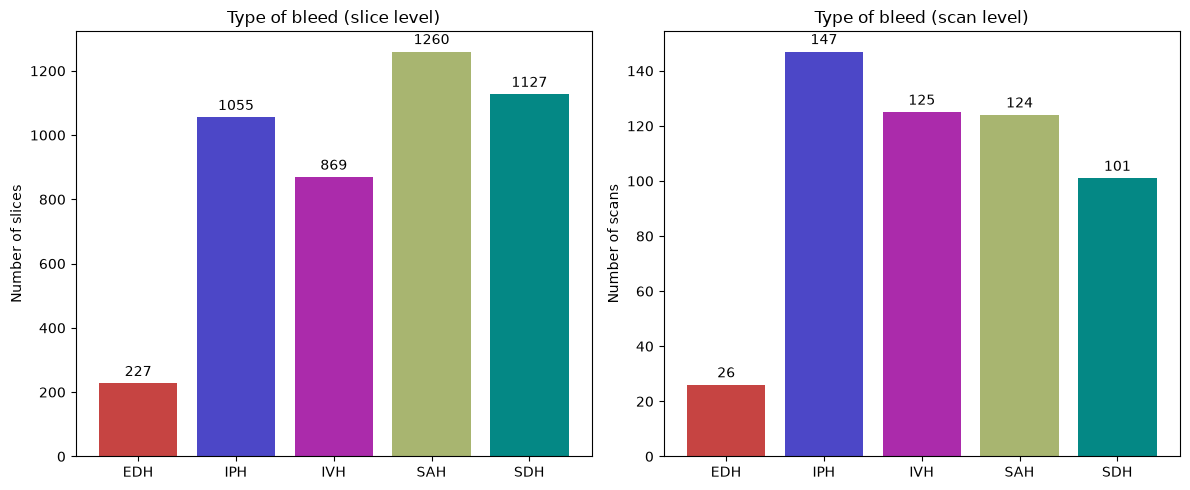

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_slice = [class_names[c] for c in sorted(slice_type_counter)]
colors_slice = [np.array(class_colors[c]) / 255 for c in sorted(slice_type_counter)]
bars0 = axes[0].bar(labels_slice, [slice_type_counter[c] for c in sorted(slice_type_counter)], color=colors_slice)
axes[0].set_title('Type of bleed (slice level)')
axes[0].set_ylabel('Number of slices')
axes[0].bar_label(bars0, padding=3)

labels_scan = [class_names[c] for c in sorted(scan_type_counter)]
colors_scan = [np.array(class_colors[c]) / 255 for c in sorted(scan_type_counter)]
bars1 = axes[1].bar(labels_scan, [scan_type_counter[c] for c in sorted(scan_type_counter)], color=colors_scan)
axes[1].set_title('Type of bleed (scan level)')
axes[1].set_ylabel('Number of scans')
axes[1].bar_label(bars1, padding=3)

plt.tight_layout()
plt.show()

#### 3.3 Volume of Bleed

In [55]:
lesion_sizes_mm3 = {c: [] for c in range(1, 6)}
lesion_sizes_vox = {c: [] for c in range(1, 6)}

for key in common_keys:
    img_sitk = sitk.ReadImage(str(image_map[key]))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))

    # SimpleITK spacing 순서: (x, y, z)
    # GetArrayFromImage 결과는 (z, y, x)이므로 곱셈 결과만 쓰면 순서 상관 없음
    spacing = np.array(img_sitk.GetSpacing(), dtype=np.float32)
    voxel_volume_mm3 = float(np.prod(spacing))

    for c in range(1, 6):
        class_mask = (mask == c)
        if not class_mask.any():
            continue

        labeled, n_components = ndimage.label(class_mask)
        sizes_vox = ndimage.sum(class_mask, labeled, index=range(1, n_components + 1))
        sizes_mm3 = sizes_vox * voxel_volume_mm3

        lesion_sizes_vox[c].extend(sizes_vox.tolist())
        lesion_sizes_mm3[c].extend(sizes_mm3.tolist())

rows = []
for c in range(1, 6):
    sizes = np.array(lesion_sizes_mm3[c], dtype=np.float32)

    if len(sizes) == 0:
        rows.append({
            'class_id': c,
            'name': class_names[c],
            'n_lesions': 0,
            'min_mm3': np.nan,
            'median_mm3': np.nan,
            'max_mm3': np.nan,
            'mean_mm3': np.nan,
        })
        continue

    rows.append({
        'class_id': c,
        'name': class_names[c],
        'n_lesions': len(sizes),
        'min_mm3': float(sizes.min()),
        'median_mm3': float(np.median(sizes)),
        'max_mm3': float(sizes.max()),
        'mean_mm3': float(sizes.mean()),
    })

df_lesion_size = pd.DataFrame(rows)
display(df_lesion_size)

,class_id,name,n_lesions,min_mm3,median_mm3,max_mm3,mean_mm3
0,1,EDH,52,0.93,982.28,117022.09,7274.36
1,2,IPH,343,0.94,1069.54,197809.95,8941.59
2,3,IVH,375,0.95,475.79,66640.95,2729.96
3,4,SAH,2259,0.75,69.11,63564.09,464.69
4,5,SDH,436,0.83,131.12,154023.84,4147.81


### 4. Visualization

In [56]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

targets = [4, 3, 2, 1]

# Collect representative scans
scan_rows = []
for key in common_keys:
    img_sitk = sitk.ReadImage(str(image_map[key]))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    img_arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)

    # scan-level: number of distinct bleed types present in the whole volume
    scan_classes = sorted(set(np.unique(mask).tolist()) - {0})
    scan_n_classes = len(scan_classes)
    if scan_n_classes == 0:
        continue

    # representative slice within the scan: slice with the largest foreground area
    slice_rows = []
    for z in range(mask.shape[0]):
        slice_classes = sorted(set(np.unique(mask[z]).tolist()) - {0})
        if not slice_classes:
            continue
        fg_voxels = int((mask[z] > 0).sum())
        slice_rows.append((z, len(slice_classes), fg_voxels))

    if not slice_rows:
        continue

    best_z, best_slice_n_classes, best_fg_voxels = max(
        slice_rows, key=lambda x: (x[2], x[1])
    )

    scan_rows.append({
        "case": key,
        "patient_id": patient_id(key),
        "scan_n_classes": scan_n_classes,
        "scan_classes": scan_classes,
        "best_z": best_z,
        "best_slice_n_classes": best_slice_n_classes,
        "best_fg_voxels": best_fg_voxels,
    })

df_scan_vis = pd.DataFrame(scan_rows)

selected_rows = []
for t in targets:
    df_t = df_scan_vis[df_scan_vis["scan_n_classes"] == t].copy()
    if df_t.empty:
        print(f"[warn] scan-level bleed count {t}인 case가 없습니다.")
        continue
    selected_rows.append(df_t.sort_values(["best_fg_voxels", "case"], ascending=[False, True]).iloc[0])

if not selected_rows:
    raise ValueError("선택할 scan이 없습니다.")

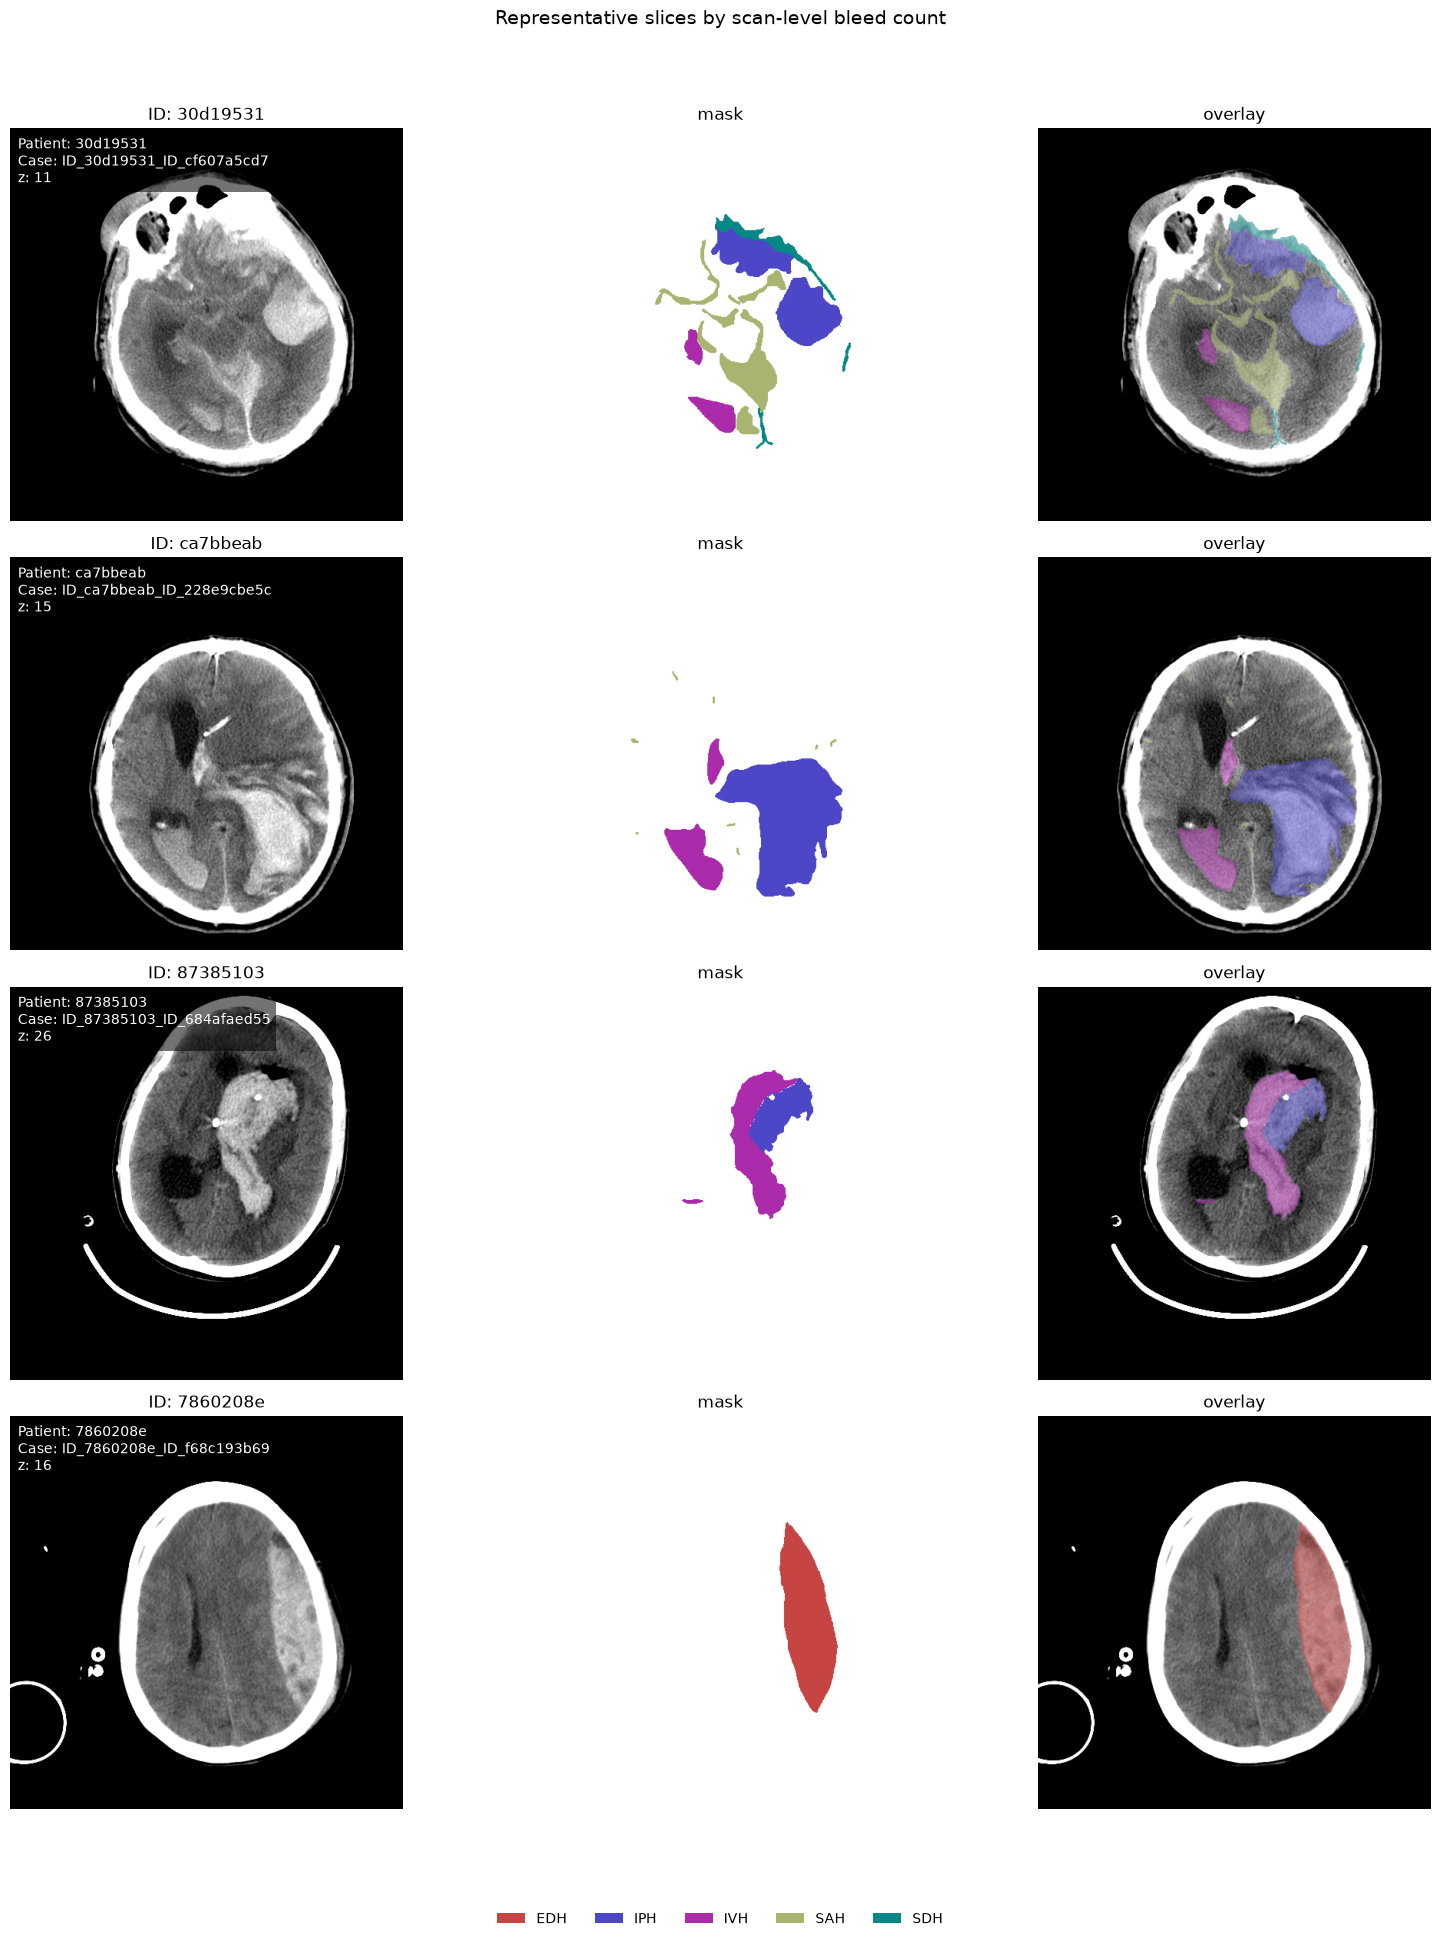

In [57]:
# Build custom colormap
n_classes = max(class_colors.keys()) + 1
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors.items():
    colors_rgb[cls] = np.array(rgb) / 255.0
custom_cmap = ListedColormap(colors_rgb)

fig, axes = plt.subplots(len(selected_rows), 3, figsize=(16, 4.8 * len(selected_rows)))
if len(selected_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in enumerate(selected_rows):
    key = row["case"]
    pid = row["patient_id"]
    z = int(row["best_z"])

    img_sitk = sitk.ReadImage(str(image_map[key]))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    img_arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)

    image_slice = apply_window(img_arr[z])
    mask_slice = mask[z]
    mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)

    axes[i, 0].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(f"ID: {pid}")
    axes[i, 0].axis("off")
    axes[i, 0].text(
        0.02, 0.98,
        f"Patient: {pid}\nCase: {key}\nz: {z}",
        transform=axes[i, 0].transAxes,
        va="top",
        ha="left",
        fontsize=10,
        color="white",
        bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=4),
    )

    axes[i, 1].set_facecolor("black")
    axes[i, 1].imshow(mask_only_display, cmap=custom_cmap, vmin=0, vmax=5)
    axes[i, 1].set_title("mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap, alpha=0.5, vmin=0, vmax=5)
    axes[i, 2].set_title("overlay")
    axes[i, 2].axis("off")

legend_handles = [
    Patch(facecolor=np.array(class_colors[c]) / 255.0, edgecolor="none", label=class_names[c])
    for c in sorted(class_colors)
]

fig.suptitle("Representative slices by scan-level bleed count", y=0.995, fontsize=14)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

## 3. nnUNet Dataset 구성

In [ ]:
import json
import shutil
from pathlib import Path

NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")
DATASET_ID = 2
DATASET_NAME = f"Dataset{DATASET_ID:03d}_MBHSeg25"

DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / DATASET_NAME
imagesTr = DATASET_DIR / "imagesTr"
labelsTr = DATASET_DIR / "labelsTr"
imagesTs = DATASET_DIR / "imagesTs"
labelsTs = DATASET_DIR / "labelsTs"  # nnUNet 공식 스펙엔 없지만, 최종 평가용으로 우리가 따로 보관
for d in (imagesTr, labelsTr, imagesTs, labelsTs):
    d.mkdir(parents=True, exist_ok=True)

ANNOTATOR_ID = 3
SOURCE_SPLITS = {
    "train": Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/mbhseg25/train"),  # -> Tr
    "val":   Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/mbhseg25/val"),    # -> Ts
}

n_train, n_test = 0, 0
for split, root in SOURCE_SPLITS.items():
    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        image_src = case_dir / "image.nii.gz"
        label_src = case_dir / f"label_annot_{ANNOTATOR_ID}.nii.gz"
        if not (image_src.exists() and label_src.exists()):
            print(f"[skip] {case_dir.name}: image 또는 annot_{ANNOTATOR_ID} 없음")
            continue

        case_id = case_dir.name
        if split == "train":
            shutil.copy2(image_src, imagesTr / f"{case_id}_0000.nii.gz")
            shutil.copy2(label_src, labelsTr / f"{case_id}.nii.gz")
            n_train += 1
        else:
            shutil.copy2(image_src, imagesTs / f"{case_id}_0000.nii.gz")
            shutil.copy2(label_src, labelsTs / f"{case_id}.nii.gz")
            n_test += 1

print(f"Train(Tr): {n_train}, Test(Ts): {n_test}")

In [ ]:
dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {
        "background": 0,
        "epidural": 1,
        "intraparenchymal": 2,
        "intraventricular": 3,
        "subarachnoid": 4,
        "subdural": 5,
    },
    "numTraining": n_train,
    "file_ending": ".nii.gz",
}
with open(DATASET_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print("dataset.json:", DATASET_DIR / "dataset.json")

In [16]:
patient_classes = {}
for key in common_keys:
    pid = case_patient[key]
    m = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    classes = set(np.unique(m).tolist()) - {0}
    patient_classes.setdefault(pid, set())
    patient_classes[pid] |= classes

patients = sorted(patient_classes.keys())
n_patients = len(patients)

rows = []
for c in range(1, 6):
    cnt = sum(1 for p in patients if c in patient_classes[p])
    rows.append({
        'class': class_names[c],
        'n_patients': cnt,
        'ratio': cnt / n_patients,
    })
display(pd.DataFrame(rows))

,class,n_patients,ratio
0,EDH,25,0.104603
1,IPH,147,0.615063
2,IVH,125,0.523013
3,SAH,123,0.514644
4,SDH,101,0.422594


In [10]:
from pathlib import Path
import SimpleITK as sitk
import numpy as np
import pandas as pd

DATASET_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset003_MBHSeg25")
labelsTr = DATASET_DIR / "labelsTr"
labelsTs = DATASET_DIR / "labelsTs"

def patient_id(cid: str) -> str:
    # ID_{patientID}_ID_{studyID} -> patientID
    return cid.split('_')[1]

def collect_patient_classes(labels_dir):
    patient_classes = {}
    for f in labels_dir.glob("*.nii.gz"):
        cid = f.name.replace(".nii.gz", "")
        pid = patient_id(cid)
        m = sitk.GetArrayFromImage(sitk.ReadImage(str(f)))
        classes = set(np.unique(m).tolist()) - {0}
        patient_classes.setdefault(pid, set())
        patient_classes[pid] |= classes
    return patient_classes

train_patient_classes = collect_patient_classes(labelsTr)
test_patient_classes = collect_patient_classes(labelsTs)

train_patients = sorted(train_patient_classes.keys())
test_patients = sorted(test_patient_classes.keys())

rows = []
for c in range(1, 6):
    train_cnt = sum(1 for p in train_patients if c in train_patient_classes[p])
    test_cnt = sum(1 for p in test_patients if c in test_patient_classes[p])
    total_cnt = train_cnt + test_cnt
    rows.append({
        'class': class_names[c],
        'train_patients': train_cnt,
        'test_patients': test_cnt,
        'test_ratio': test_cnt / total_cnt if total_cnt else 0,
    })
display(pd.DataFrame(rows))

,class,train_patients,test_patients,test_ratio
0,EDH,22,3,0.120000
1,IPH,127,20,0.136054
2,IVH,107,18,0.144000
3,SAH,111,12,0.097561
4,SDH,81,20,0.198020


* 1cls

In [13]:
import shutil
import SimpleITK as sitk
import numpy as np
import json
from pathlib import Path

NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")
SRC_DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / "Dataset003_MBHSeg25"
DST_DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / "Dataset004_MBHSeg25_1cls"

src_imagesTr, src_labelsTr = SRC_DATASET_DIR / "imagesTr", SRC_DATASET_DIR / "labelsTr"
src_imagesTs, src_labelsTs = SRC_DATASET_DIR / "imagesTs", SRC_DATASET_DIR / "labelsTs"

dst_imagesTr = DST_DATASET_DIR / "imagesTr"
dst_labelsTr = DST_DATASET_DIR / "labelsTr"
dst_imagesTs = DST_DATASET_DIR / "imagesTs"
dst_labelsTs = DST_DATASET_DIR / "labelsTs"
for d in (dst_imagesTr, dst_labelsTr, dst_imagesTs, dst_labelsTs):
    d.mkdir(parents=True, exist_ok=True)

In [12]:
# mask 변환
def convert_to_1cls(src_path: Path, dst_path: Path):
    img = sitk.ReadImage(str(src_path))
    arr = sitk.GetArrayFromImage(img)          # 정수 라벨맵 (0,1,2,3,4,5)
    arr_1cls = (arr > 0).astype(np.uint8)       # 0이 아니면 전부 1
    out = sitk.GetImageFromArray(arr_1cls)
    out.CopyInformation(img)                    # spacing/origin/direction 반드시 유지
    sitk.WriteImage(out, str(dst_path))

In [16]:
# 이미지는 그대로 복사 (Tr/Ts split을 MBHSeg25와 동일하게 유지)
for src_dir, dst_dir in [(src_imagesTr, dst_imagesTr), (src_imagesTs, dst_imagesTs)]:
    for f in src_dir.glob("*.nii.gz"):
        shutil.copy2(f, dst_dir / f.name)

# 라벨은 변환해서 저장
for src_dir, dst_dir in [(src_labelsTr, dst_labelsTr), (src_labelsTs, dst_labelsTs)]:
    for f in src_dir.glob("*.nii.gz"):
        convert_to_1cls(f, dst_dir / f.name)

n_train = len(list(dst_imagesTr.glob("*.nii.gz")))
dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "ich": 1},
    "numTraining": n_train,
    "file_ending": ".nii.gz",
}
with open(DST_DATASET_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print(f"Tr images: {len(list(dst_imagesTr.glob('*.nii.gz')))}, "
      f"Tr labels: {len(list(dst_labelsTr.glob('*.nii.gz')))}, "
      f"Ts images: {len(list(dst_imagesTs.glob('*.nii.gz')))}, "
      f"Ts labels: {len(list(dst_labelsTs.glob('*.nii.gz')))}")

Tr images: 192, Tr labels: 192, Ts images: 48, Ts labels: 48


In [39]:
# 변환 확인
# 숫자

DATASET_1CLS_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset004_MBHSeg25_1cls")
train_only_keys = [k for k in common_keys if case_split[k] == "train"]
patient_key = train_only_keys[0]
cid = patient_key.replace(".nii.gz", "")

img_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(DATASET_1CLS_DIR / "imagesTr" / f"{cid}_0000.nii.gz")))
mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(DATASET_1CLS_DIR / "labelsTr" / f"{cid}.nii.gz")))
print("마스크 고유값:", np.unique(mask_arr))

num_slices = 15
target_slice_img = img_arr[num_slices]
target_slice_mask = mask_arr[num_slices]

ys, xs = np.where(target_slice_mask > 0)

if len(xs) == 0:
    print(f"{num_slices}번 슬라이스에는 병변이 없습니다.")
else:
    margin = 10
    y0, y1 = max(ys.min() - margin, 0), min(ys.max() + margin, target_slice_mask.shape[0])
    x0, x1 = max(xs.min() - margin, 0), min(xs.max() + margin, target_slice_mask.shape[1])

    cropped_img = target_slice_img[y0:y1, x0:x1]
    cropped_mask = target_slice_mask[y0:y1, x0:x1]

    print("crop 영역 (y0:y1, x0:x1):", (y0, y1, x0, x1))
    print("crop된 이미지 배열:\n", cropped_img)
    print("\ncrop된 마스크 배열(0/1만 있어야 함):\n", cropped_mask)
    print("마스크 고유값:", np.unique(cropped_mask))  # [0, 1]만 나오면 변환 성공

마스크 고유값: [0 1]
crop 영역 (y0:y1, x0:x1): (np.int64(248), np.int64(355), np.int64(249), np.int64(314))
crop된 이미지 배열:
 [[ 9 13 12 ... 36 37 34]
 [ 9 10 11 ... 34 39 36]
 [11 11 12 ... 33 39 35]
 ...
 [53 46 32 ... 27 20 22]
 [52 45 34 ... 29 22 22]
 [51 43 34 ... 32 28 26]]

crop된 마스크 배열(0/1만 있어야 함):
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
마스크 고유값: [0 1]


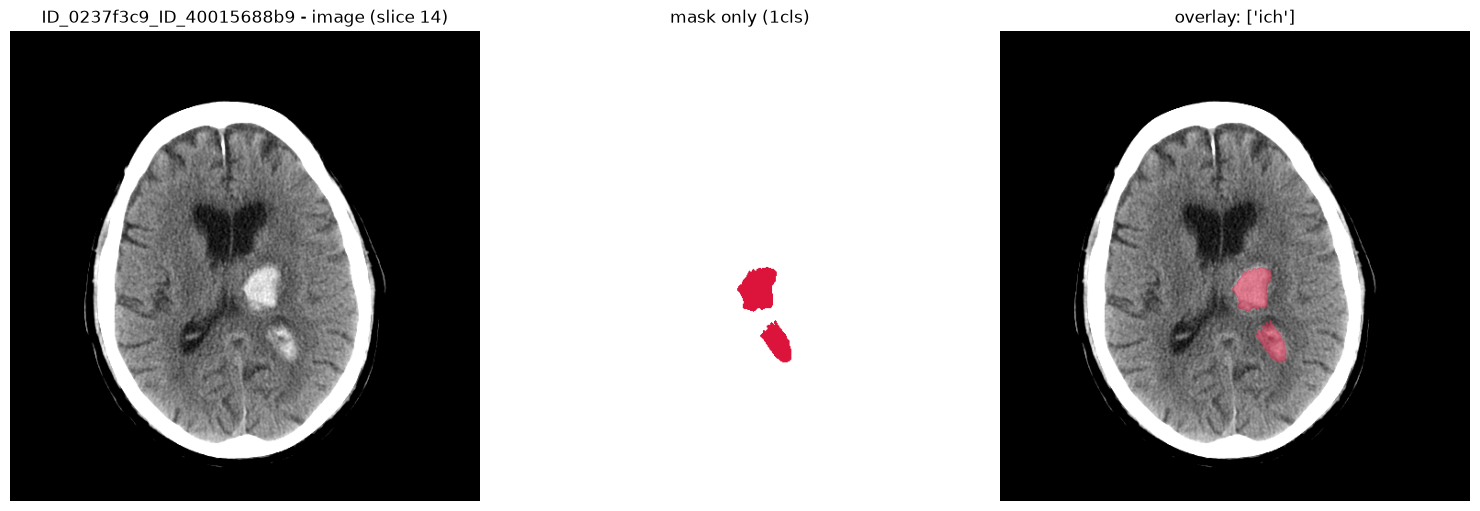

In [ ]:
# 이미지

class_names_1cls = {1: 'ich'}
class_colors_1cls = {1: (220, 20, 60)}

fg_voxels_per_slice = (mask_arr > 0).sum(axis=(1, 2))
best_z = int(np.argmax(fg_voxels_per_slice))

windowed_slice = apply_window(img_arr[best_z])
mask_slice = mask_arr[best_z]
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{cid} - image (slice {best_z})')
axes[0].axis('off')

n_classes = max(class_colors_1cls.keys()) + 1   # 1 + 1 = 2 (0, 1)
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb[cls] = np.array(rgb) / 255
custom_cmap = ListedColormap(colors_rgb)

mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)
axes[1].set_facecolor('black')
axes[1].imshow(mask_only_display, cmap=custom_cmap, vmin=0, vmax=1)
axes[1].set_title('mask only (1cls)')
axes[1].axis('off')

axes[2].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(mask_overlay, cmap=custom_cmap, alpha=0.5, vmin=0, vmax=1)
present = [class_names_1cls[c] for c in np.unique(mask_slice) if c != 0]
axes[2].set_title(f'overlay: {present}')
axes[2].axis('off')
plt.tight_layout()
plt.show()